In [ ]:
# Elevation, slope, and aspect for the building footprints

DEM loaded successfully!
Shape: (2291, 4342)
CRS: EPSG:4326
Bounds: BoundingBox(left=-0.520138888505, bottom=5.470694443221, right=0.6859722235709997, top=6.107083332619)
Resolution: (0.0002777777779999999, 0.0002777777779999999)
Min elevation (clean): -43.0 m
Max elevation (clean): 433.0 m
Mean elevation: 38.8 m


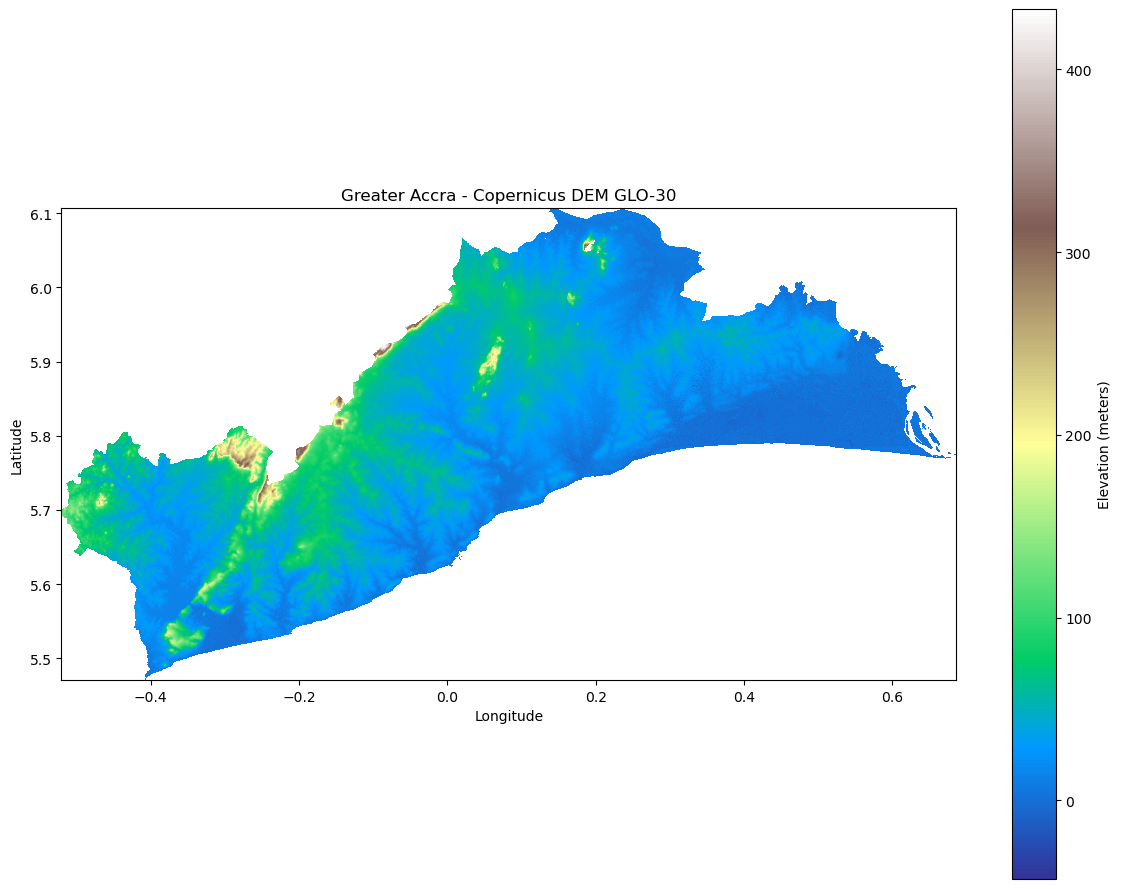

In [10]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

# Load DEM
dem_path = r'I:\GEO DATA ANALYSIS\solar_ghana\greater_accra_dem.tif'

with rasterio.open(dem_path) as src:
    dem = src.read(1)
    transform = src.transform
    bounds = src.bounds
    crs = src.crs

# Clean NoData values
nodata = src.nodata
if nodata is not None:
    dem_clean = np.where(dem == nodata, np.nan, dem)
else:
    dem_clean = dem.astype(float)

print(f"DEM loaded successfully!")
print(f"Shape: {dem.shape}")
print(f"CRS: {crs}")
print(f"Bounds: {bounds}")
print(f"Resolution: {src.res}")
print(f"Min elevation (clean): {np.nanmin(dem_clean):.1f} m")
print(f"Max elevation (clean): {np.nanmax(dem_clean):.1f} m")
print(f"Mean elevation: {np.nanmean(dem_clean):.1f} m")

# Plot 
fig, ax = plt.subplots(figsize=(12, 9))


im = ax.imshow(dem_clean, 
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               cmap="terrain", 
               interpolation='nearest')

ax.set_title("Greater Accra - Copernicus DEM GLO-30")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add colorbar
cbar = fig.colorbar(im, ax=ax, label="Elevation (meters)")
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Calculate Slope and Aspect

import numpy as np
import rasterio

# Calculate Slope and Aspect
dz_dy, dz_dx = np.gradient(dem_clean)

slope_deg = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)) * (180 / np.pi)
aspect_deg = np.arctan2(-dz_dx, dz_dy) * (180 / np.pi)
aspect_deg = np.mod(aspect_deg, 360)

# Mask NoData
slope_deg = np.where(np.isnan(dem_clean), np.nan, slope_deg)
aspect_deg = np.where(np.isnan(dem_clean), np.nan, aspect_deg)

print(f"\nSlope Statistics:")
print(f"   Min: {np.nanmin(slope_deg):.1f}°")
print(f"   Max: {np.nanmax(slope_deg):.1f}°")
print(f"   Mean: {np.nanmean(slope_deg):.1f}°")

print(f"\nAspect Statistics:")
print(f"   Min: {np.nanmin(aspect_deg):.1f}°")
print(f"   Max: {np.nanmax(aspect_deg):.1f}°")

# Save
with rasterio.open(dem_path) as src:
    profile = src.profile.copy()
    profile.update(dtype=rasterio.float32, nodata=np.nan, compress='LZW')

    slope_path = "accra_slope.tif"
    aspect_path = "accra_aspect.tif"

    with rasterio.open(slope_path, 'w', **profile) as dst:
        dst.write(slope_deg.astype(rasterio.float32), 1)

    with rasterio.open(aspect_path, 'w', **profile) as dst:
        dst.write(aspect_deg.astype(rasterio.float32), 1)

print(f"\nSuccessfully saved:")
print(f"   → accra_slope.tif")
print(f"   → accra_aspect.tif")


Slope Statistics:
   Min: 0.0°
   Max: 88.8°
   Mean: 51.1°

Aspect Statistics:
   Min: 0.0°
   Max: 358.4°

Successfully saved:
   → accra_slope.tif
   → accra_aspect.tif
